# 30 — False-positive/false-negative and test-set credibility audit

This audit follows the accepted development result in notebook 29. It does not retrain or tune a model and it does not load RevalExo or NONAN signals. It asks two separate questions: **where does the selected lower-back ensemble fail?** and **is the available evaluation evidence credible enough for a final clinical claim?**

The classification threshold remains 0.50. Error counts are calculated at participant level. Five seeds are repeated model fits, not five independent copies of each participant, so confidence intervals are calculated only from one cross-seed consensus prediction per participant.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
PROCESSED = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
decision = json.loads((PROCESSED / 'evidence_gated_lower_back_dg_decision.json').read_text())
metrics = pd.read_csv(PROCESSED / 'evidence_gated_lower_back_dg_metrics.csv')
predictions = pd.read_csv(PROCESSED / 'evidence_gated_lower_back_dg_participant_predictions.csv')
selected = decision['selected_method']
assert selected == 'ensemble_all'
assert decision['frozen_cohorts_loaded'] is False
print('Selected development method:', selected)
print('Frozen signal cohorts loaded by this audit: NONE')


Selected development method: ensemble_all
Frozen signal cohorts loaded by this audit: NONE


In [2]:
per_seed = metrics.query("method == @selected and evaluation_source != 'pooled'").copy()
error_by_source = per_seed.groupby('held_out_source', as_index=False).agg(
    healthy=('healthy', 'first'), stroke=('stroke', 'first'),
    mean_fp=('false_positives', 'mean'), min_fp=('false_positives', 'min'), max_fp=('false_positives', 'max'),
    mean_fn=('false_negatives', 'mean'), min_fn=('false_negatives', 'min'), max_fn=('false_negatives', 'max'),
    mean_specificity=('specificity', 'mean'), mean_sensitivity=('sensitivity', 'mean'),
)
error_by_source.to_csv(PROCESSED / 'lower_back_ensemble_fp_fn_by_source.csv', index=False)
display(error_by_source.round(3))


,held_out_source,healthy,stroke,mean_fp,min_fp,max_fp,mean_fn,min_fn,max_fn,mean_specificity,mean_sensitivity
0,felius_2024,34,129,8.0,6,11,30.6,13,42,0.765,0.763
1,sint_maartenskliniek,20,10,4.0,4,4,1.2,1,2,0.800,0.880
2,voisard_2025,72,49,17.4,11,24,4.0,1,11,0.758,0.918


In [3]:
def wilson(successes, total, z=1.959963984540054):
    p = successes / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    half = z * math.sqrt(p*(1-p)/total + z*z/(4*total*total)) / denominator
    return center-half, center+half

consensus = predictions.query('method == @selected').groupby(
    ['source', 'group', 'y'], as_index=False
).agg(probability=('probability', 'mean'), probability_sd=('probability', 'std'))
consensus['prediction'] = (consensus['probability'] >= 0.50).astype(int)
consensus['error_type'] = np.select(
    [(consensus.y == 0) & (consensus.prediction == 1), (consensus.y == 1) & (consensus.prediction == 0)],
    ['FP', 'FN'], default='correct'
)
rows = []
for source, frame in consensus.groupby('source', sort=True):
    tn = int(((frame.y == 0) & (frame.prediction == 0)).sum())
    fp = int(((frame.y == 0) & (frame.prediction == 1)).sum())
    fn = int(((frame.y == 1) & (frame.prediction == 0)).sum())
    tp = int(((frame.y == 1) & (frame.prediction == 1)).sum())
    spec_ci = wilson(tn, tn + fp)
    sens_ci = wilson(tp, tp + fn)
    rows.append(dict(source=source, TN=tn, FP=fp, FN=fn, TP=tp,
                     specificity=tn/(tn+fp), specificity_ci_low=spec_ci[0], specificity_ci_high=spec_ci[1],
                     sensitivity=tp/(tp+fn), sensitivity_ci_low=sens_ci[0], sensitivity_ci_high=sens_ci[1]))
confusion = pd.DataFrame(rows)
total = consensus.copy()
tn = int(((total.y == 0) & (total.prediction == 0)).sum()); fp = int(((total.y == 0) & (total.prediction == 1)).sum())
fn = int(((total.y == 1) & (total.prediction == 0)).sum()); tp = int(((total.y == 1) & (total.prediction == 1)).sum())
spec_ci = wilson(tn, tn+fp); sens_ci = wilson(tp, tp+fn)
confusion = pd.concat([confusion, pd.DataFrame([dict(source='pooled diagnostic', TN=tn, FP=fp, FN=fn, TP=tp,
    specificity=tn/(tn+fp), specificity_ci_low=spec_ci[0], specificity_ci_high=spec_ci[1],
    sensitivity=tp/(tp+fn), sensitivity_ci_low=sens_ci[0], sensitivity_ci_high=sens_ci[1])])], ignore_index=True)
confusion.to_csv(PROCESSED / 'lower_back_ensemble_seed_consensus_confusion.csv', index=False)
consensus.query("error_type != 'correct'").sort_values(['error_type','probability']).to_csv(
    PROCESSED / 'lower_back_ensemble_persistent_errors.csv', index=False
)
display(confusion.round(3))
print('Persistent participant errors:', consensus.error_type.value_counts().to_dict())


,source,TN,FP,FN,TP,specificity,specificity_ci_low,specificity_ci_high,sensitivity,sensitivity_ci_low,sensitivity_ci_high
0,felius_2024,26,8,28,101,0.765,0.600,0.876,0.783,0.704,0.845
1,sint_maartenskliniek,16,4,1,9,0.800,0.584,0.919,0.900,0.596,0.982
2,voisard_2025,57,15,4,45,0.792,0.684,0.869,0.918,0.808,0.968
3,pooled diagnostic,99,27,33,155,0.786,0.706,0.848,0.824,0.764,0.872


Persistent participant errors: {'correct': 254, 'FN': 33, 'FP': 27}


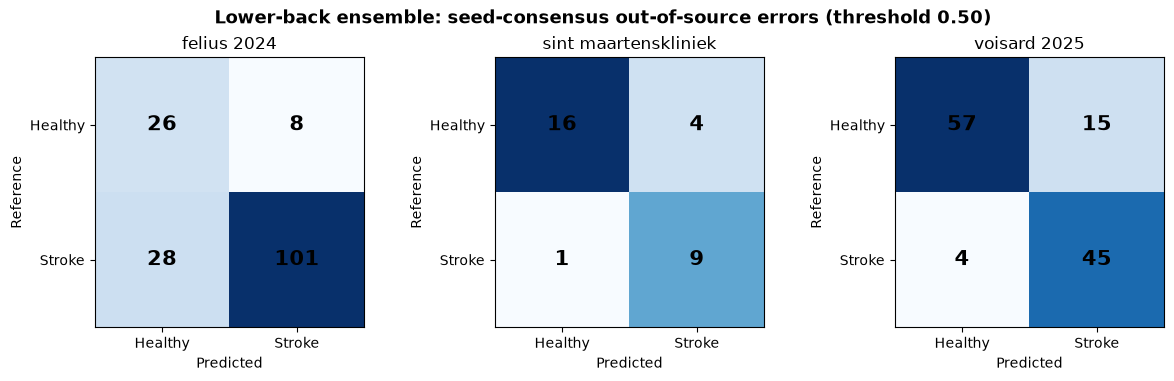

Saved: reports\lower_back_ensemble_fp_fn_confusion.png


In [4]:
source_rows = confusion.query("source != 'pooled diagnostic'")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), constrained_layout=True)
for ax, row in zip(axes, source_rows.itertuples()):
    matrix = np.array([[row.TN, row.FP], [row.FN, row.TP]])
    ax.imshow(matrix, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i,j]), ha='center', va='center', fontsize=15, fontweight='bold')
    ax.set_xticks([0,1], ['Healthy', 'Stroke']); ax.set_yticks([0,1], ['Healthy', 'Stroke'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Reference'); ax.set_title(row.source.replace('_',' '))
fig.suptitle('Lower-back ensemble: seed-consensus out-of-source errors (threshold 0.50)', fontsize=13, fontweight='bold')
figure_path = REPORTS / 'lower_back_ensemble_fp_fn_confusion.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', figure_path.relative_to(ROOT))


## How comparable work constructs evaluation sets

| Source | Participants/evaluation design | What it teaches this project |
|---|---|---|
| [Felius et al., 2024](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0304558) | Participant-level 70/20/10 train/test/validation, repeated ten times; 77 longitudinal stroke participants plus 30 stroke and 37 healthy test-retest participants | Participant isolation and repeated evaluation are appropriate, but this is still development-style evidence rather than a new-site final binary test. |
| [Wang et al., 2025](https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2025.1544372/full) | 156 training participants and a 70-person holdout (58 healthy, 12 stroke). The reported KNN/SVM confusion result was TN=57, FP=1, TP=8, FN=4 | A large class imbalance can yield 92.9% overall accuracy while stroke sensitivity is only 66.7%; class-specific FP/FN counts are indispensable. |
| [STAT-GCN study, 2026](https://rehab.jmir.org/2026/1/e94031) | Stratified participant-level five-fold CV over 51 stroke and 18 healthy participants; all cycles from one person stay in one fold and training augmentation never enters test | This is a good internal-validation split discipline, but it is not an independent external site. |
| [Riley et al./BMJ external-validation guidance, 2024](https://www.bmj.com/content/384/bmj-2023-074821) | Warns that many external validations are too small; 100 events and 100 non-events is only a starting rule, with model- and setting-specific precision calculations preferred | A 17-person external set cannot support a precise reliability claim even if it is genuinely independent. |
| [FDA diagnostic-test reporting guidance](https://www.fda.gov/regulatory-information/search-fda-guidance-documents/statistical-guidance-reporting-results-studies-evaluating-diagnostic-tests-guidance-industry-and-fda) | Requires 2×2 counts, two-sided 95% intervals, complete participant accounting, site and subgroup results, representative demographics, disease spectrum, and relevant confounding conditions | Final testing must include more than easy healthy controls and clear stroke cases; non-stroke gait disorders and clinically relevant subgroups are necessary. |


In [5]:
def minimum_n_for_wilson_width(expected_rate, target_width=0.10):
    for n in range(2, 10000):
        low, high = wilson(round(expected_rate*n), n)
        if high - low <= target_width:
            return n, low, high
    raise RuntimeError('Search bound exceeded')

pooled = confusion.query("source == 'pooled diagnostic'").iloc[0]
healthy_n, hlo, hhi = minimum_n_for_wilson_width(pooled.specificity)
stroke_n, slo, shi = minimum_n_for_wilson_width(pooled.sensitivity)
precision_plan = pd.DataFrame([
    {'target':'specificity', 'planning_rate':pooled.specificity, 'participants_needed_for_95pct_CI_width_le_0.10':healthy_n},
    {'target':'sensitivity', 'planning_rate':pooled.sensitivity, 'participants_needed_for_95pct_CI_width_le_0.10':stroke_n},
])
display(precision_plan.round(3))
print('Interpretation: about', healthy_n, 'independent non-stroke/healthy and', stroke_n,
      'independent stroke participants are needed merely to target a total 95% CI width of 10 percentage points at the observed rates.')


,target,planning_rate,participants_needed_for_95pct_CI_width_le_0.10
0,specificity,0.786,257
1,sensitivity,0.824,222


Interpretation: about 257 independent non-stroke/healthy and 222 independent stroke participants are needed merely to target a total 95% CI width of 10 percentage points at the observed rates.


## Credibility verdict

The current three-source leave-one-source-out design is credible for **development model selection**: participants and complete sources are isolated, preprocessing is training-only, results are repeated, and errors are reported by source. It is not a credible **final clinical test** because every development source influenced method selection, the paired external RevalExo cohort has only 7 healthy and 10 stroke participants, repeated historical inspection weakens its status as a pristine final test, and the one-sided healthy/stroke component cohorts cannot be merged into a binary test.

A defensible final test must lock the complete lower-back ensemble and threshold first, use previously unseen participants from independent sites/devices, retain one participant as one statistical unit, include the intended age/sex/severity/walking-aid spectrum and non-stroke gait confounders, and report TP/FP/TN/FN plus confidence intervals by site and subgroup. The 100 stroke + 100 non-event rule is only a starting floor. At this experiment's observed rates, a planning target of a 10-percentage-point-wide 95% Wilson interval requires approximately the calculated 222 stroke and 257 healthy/non-stroke participants.
